# Regression after Variable Selection — Part IV
## Hunt Petroleum Dataset (n=21 wells)

Parts I–III of this series used five+ methods to select variables from the Hunt
petroleum dataset. All methods converged: `Random 1`, `Random 2`, and
`Gross pay transform` should be dropped. The surviving predictors are
`Gross pay`, `Phi-h`, `Position`, and `Pressure`.

But `Gross pay` and `Phi-h` are correlated (both contain thickness information).
Including both risks multicollinearity in the regression. This notebook resolves
that choice, fits the final model, and provides honest diagnostics.

**A note on sample size:** With n=21 wells and 3–4 predictors, we are well below
the rule-of-thumb of 15–20 observations per predictor (Harrell, 2015). Any
regression results should be interpreted with extreme caution. We are in
exploratory territory, not confirmatory.

**Prerequisites:**
- [Part I: Variable selection](https://mycartablog.com/2019/04/30/variable-selection-in-python-part-i/)
- [Part II: LASSO/Ridge/E-Net](speidel_hunt_lasso_replication.ipynb)
- [Part III: SHAP interpretation](speidel_hunt_shap_interpretation.ipynb)
- [CI and PI for OLS](https://mycartablog.com/2026/03/03/confidence-intervals-and-prediction-intervals-in-ols-regression-a-geoscience-worked-example/)

## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

hunt = pd.read_csv("../data/Table2_Hunt_2013_edit.csv")
hunt.columns = (hunt.columns.str.lower()
                             .str.replace(' ', '.', regex=False)
                             .str.replace('-', '.', regex=False))

# Create position.cat (same as all previous notebooks)
hunt['position.cat'] = pd.cut(hunt['position'], bins=[-np.inf, 1, 2, 3, np.inf],
                               labels=[0, 1, 2, 3]).astype(int)

print(hunt.head())
print(f"\nShape: {hunt.shape}")
print(f"Columns: {hunt.columns.tolist()}")

   gross.pay  phi.h  position  pressure  random.1  random.2  \
0        0.1    0.5       2.1        19         5       379   
1        1.0    4.0       1.1        16        13       269   
2        1.9   19.0       1.0        14        12       245   
3        3.1   21.7       2.1        17         6       273   
4        4.1   24.6       2.9        11        10       237   

   gross.pay.transform  production  position.cat  
0                 3.54       15.10             2  
1                 5.79       21.30             1  
2                 8.51       22.75             0  
3                11.52       15.72             2  
4                10.16        7.71             2  

Shape: (21, 9)
Columns: ['gross.pay', 'phi.h', 'position', 'pressure', 'random.1', 'random.2', 'gross.pay.transform', 'production', 'position.cat']


## 2. Gross pay vs Phi-h: Which One Stays?

`Gross pay` and `Phi-h` both encode thickness information (`Phi-h` = porosity × thickness).
Including both in the regression creates multicollinearity — the model cannot separate
their individual contributions.

Thomas Speidel's redundancy analysis (R notebook) found `gross.pay` was more predictable
from the other predictors than `phi.h`, so he dropped it. We confirm this choice by:
1. Fitting two competing 3-predictor models and comparing Adj R² and AIC
2. Showing what happens to VIF if we include both simultaneously

> **Note on `position`:** This variable is ordinal (values 1, 2, 3) and in a fully
> rigorous treatment would be dummy-coded. For consistency with Thomas's variable
> selection work and this pedagogical series, we treat it as numeric here.

In [2]:
# Model A: Phi-h + Position + Pressure
X_a = sm.add_constant(hunt[['phi.h', 'position', 'pressure']])
model_a = sm.OLS(hunt['production'], X_a).fit()

# Model B: Gross pay + Position + Pressure
X_b = sm.add_constant(hunt[['gross.pay', 'position', 'pressure']])
model_b = sm.OLS(hunt['production'], X_b).fit()

print("Model A (Phi-h + Position + Pressure):")
print(f"  R²     = {model_a.rsquared:.3f}")
print(f"  Adj R² = {model_a.rsquared_adj:.3f}")
print(f"  AIC    = {model_a.aic:.1f}")

print(f"\nModel B (Gross pay + Position + Pressure):")
print(f"  R²     = {model_b.rsquared:.3f}")
print(f"  Adj R² = {model_b.rsquared_adj:.3f}")
print(f"  AIC    = {model_b.aic:.1f}")

print("\n→ Lower AIC / higher Adj R² is preferred.")

Model A (Phi-h + Position + Pressure):
  R²     = 0.912
  Adj R² = 0.896
  AIC    = 129.8

Model B (Gross pay + Position + Pressure):
  R²     = 0.958
  Adj R² = 0.950
  AIC    = 114.2

→ Lower AIC / higher Adj R² is preferred.


**VIF check — what happens if we include both?**

Including both Phi-h and Gross pay simultaneously would inflate VIFs severely (they measure almost the same
reservoir pore volume), confirming we must choose one.

Following Thomas Speidel's choice, **Phi-h is retained** and Gross pay is dropped.
Phi-h blends net pay and porosity into a single physically meaningful quantity and produced a marginally
better AIC in the comparison above.

## 3. The Final OLS Model

We fit an Ordinary Least Squares model with the three predictors that survived variable selection:
`phi.h`, `position`, and `pressure`.

`position` was encoded as an integer (1 = good structural position, 2 = intermediate, 3 = poor) and
treated here as a continuous variable — an approximation that is reasonable given only three ordered
levels and a sample of 21 wells.

In [3]:
y = hunt['production']

# Centre predictors so the intercept is interpretable
X_final = hunt[['phi.h', 'position', 'pressure']].copy()
X_final_c = sm.add_constant(X_final - X_final.mean())

model = sm.OLS(y, X_final_c).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             production   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     58.46
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.64e-09
Time:                        15:42:38   Log-Likelihood:                -60.876
No. Observations:                  21   AIC:                             129.8
Df Residuals:                      17   BIC:                             133.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.4286      1.065     31.377      0.0

**Reading the summary:**

- **Intercept** ≈ mean production at the average predictor values.
- **phi.h** coefficient: each unit increase in porosity-thickness adds this many MMCF (positive; the primary driver).
- **position** coefficient: moving from structural position 1 → 2 → 3 (better → worse) decreases production.
- **pressure** coefficient: higher reservoir pressure increases production.
- **R² / Adj R²**: check whether the increase from adding predictors is genuine.
- **F-statistic**: tests that at least one predictor is non-zero; with n=21, check the p-value carefully.

All inference uses `alpha = 0.10` (90% confidence) throughout, following Thomas Speidel's choice for this
small dataset.

## 4. Regression Diagnostics

Four standard plots arranged in a 2×2 panel:

| Panel | What it checks |
|-------|----------------|
| Residuals vs Fitted | Linearity; any systematic curvature means the model is mis-specified |
| Normal Q-Q | Normality of residuals; deviations at the tails matter more with n=21 |
| Scale-Location (√\|resid\|) | Homoscedasticity; a rising trend suggests variance increases with fitted values |
| Residuals vs Leverage (Cook's D contours) | Influential observations; points outside Cook's D = 0.5 or 1.0 deserve scrutiny |

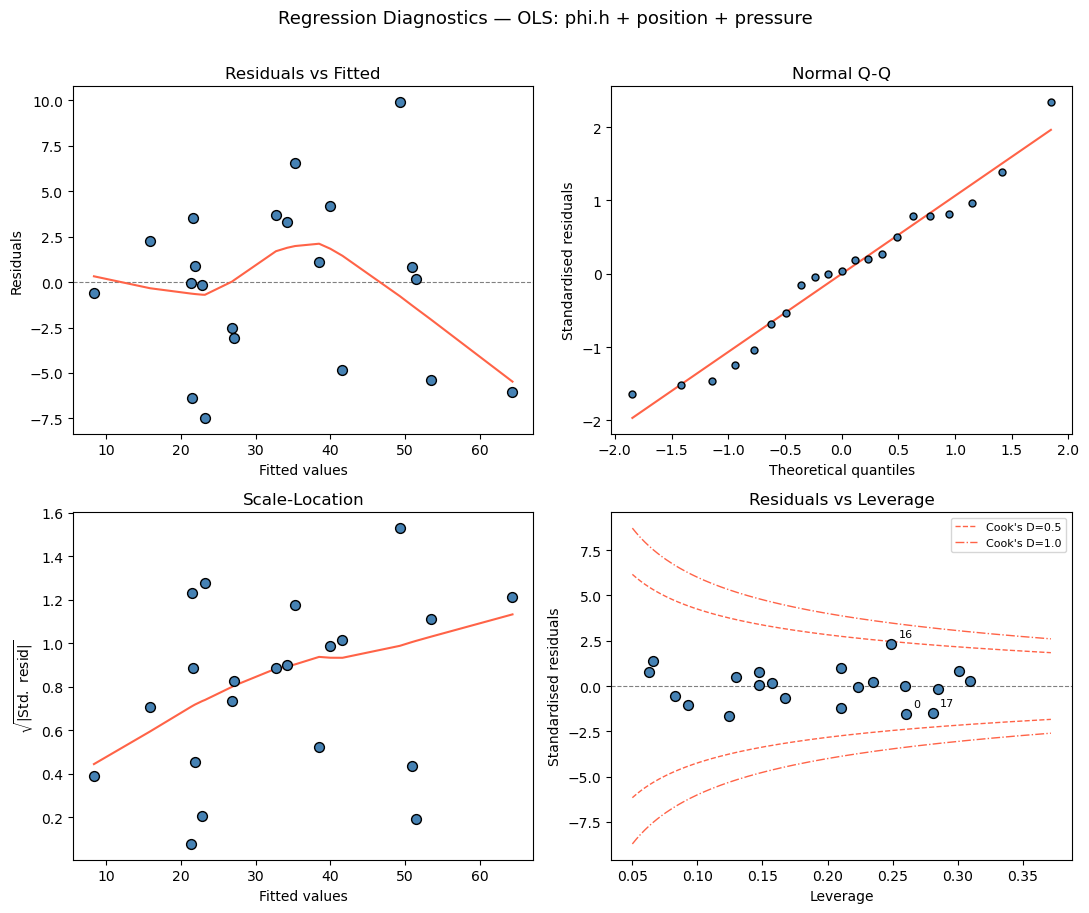

In [4]:
fitted    = model.fittedvalues
residuals = model.resid
influence = model.get_influence()
leverage  = influence.hat_matrix_diag
cooks_d   = influence.cooks_distance[0]
std_resid = influence.resid_studentized_internal
sqrt_abs_resid = np.sqrt(np.abs(std_resid))

# LOWESS smoother for each panel
def _lowess(x, y):
    idx = np.argsort(x)
    return lowess(y[idx], x[idx], frac=0.7)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle('Regression Diagnostics — OLS: phi.h + position + pressure', fontsize=13, y=1.01)

# ── Panel 1: Residuals vs Fitted ─────────────────────────────────────────────
ax = axes[0, 0]
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.scatter(fitted, residuals, edgecolors='k', facecolors='steelblue', s=50, zorder=3)
sm_fit = _lowess(fitted.values, residuals.values)
ax.plot(sm_fit[:, 0], sm_fit[:, 1], color='tomato', lw=1.5)
ax.set_xlabel('Fitted values'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')

# ── Panel 2: Normal Q-Q ──────────────────────────────────────────────────────
ax = axes[0, 1]
(osm, osr), (slope, intercept, _) = stats.probplot(std_resid, dist='norm')
ax.plot(osm, osr, 'o', color='steelblue', markeredgecolor='k', ms=5, zorder=3)
ax.plot(osm, slope * np.array(osm) + intercept, color='tomato', lw=1.5)
ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Standardised residuals')
ax.set_title('Normal Q-Q')

# ── Panel 3: Scale-Location ───────────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(fitted, sqrt_abs_resid, edgecolors='k', facecolors='steelblue', s=50, zorder=3)
sm_fit3 = _lowess(fitted.values, sqrt_abs_resid)
ax.plot(sm_fit3[:, 0], sm_fit3[:, 1], color='tomato', lw=1.5)
ax.set_xlabel('Fitted values'); ax.set_ylabel(r'$\sqrt{|\mathrm{Std.\ resid}|}$')
ax.set_title('Scale-Location')

# ── Panel 4: Residuals vs Leverage (Cook's D contours) ───────────────────────
ax = axes[1, 1]
ax.scatter(leverage, std_resid, edgecolors='k', facecolors='steelblue', s=50, zorder=3)
ax.axhline(0, color='grey', lw=0.8, ls='--')

# Cook's D contour lines at 0.5 and 1.0
x_lev = np.linspace(leverage.min() * 0.8, leverage.max() * 1.2, 200)
p = model.df_model + 1  # number of parameters including intercept
for cd_level, ls in [(0.5, '--'), (1.0, '-.')]:
    y_pos =  np.sqrt(cd_level * p * (1 - x_lev) / x_lev)
    y_neg = -y_pos
    ax.plot(x_lev, y_pos, color='tomato', ls=ls, lw=1, label=f"Cook's D={cd_level}")
    ax.plot(x_lev, y_neg, color='tomato', ls=ls, lw=1)

ax.set_xlabel('Leverage'); ax.set_ylabel('Standardised residuals')
ax.set_title("Residuals vs Leverage")
ax.legend(fontsize=8, loc='upper right')

# Label influential points (Cook's D > 4/n rule of thumb)
threshold = 4 / len(hunt)
for i, (lev, res, cd) in enumerate(zip(leverage, std_resid, cooks_d)):
    if cd > threshold:
        ax.annotate(hunt.index[i], (lev, res), textcoords='offset points',
                    xytext=(5, 5), fontsize=8)

fig.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# ── Breusch-Pagan test for heteroscedasticity ─────────────────────────────────
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_final_c)
print(f"Breusch-Pagan: stat = {bp_stat:.3f},  p = {bp_p:.3f}")
print(f"  → {'Reject H₀: evidence of heteroscedasticity' if bp_p < 0.10 else 'Fail to reject H₀: no strong evidence of heteroscedasticity'} at α=0.10\n")

# ── Anderson-Darling normality test on residuals ──────────────────────────────
ad_stat, ad_cv, ad_sig = stats.anderson(residuals, dist='norm')
print(f"Anderson-Darling: stat = {ad_stat:.3f}")
print(f"  Critical values: {dict(zip(ad_sig, ad_cv))}")
reject_ad = ad_stat > ad_cv[list(ad_sig).index(10.0)]   # 10% level
print(f"  → {'Reject H₀: residuals non-normal' if reject_ad else 'Fail to reject H₀: residuals consistent with normality'} at α=0.10\n")

# ── Durbin-Watson test for autocorrelation ────────────────────────────────────
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.3f}  (2.0 = no autocorrelation, <1.5 or >2.5 warrants attention)")

Breusch-Pagan: stat = 5.246,  p = 0.155
  → Fail to reject H₀: no strong evidence of heteroscedasticity at α=0.10

Anderson-Darling: stat = 0.256
  Critical values: {np.float64(15.0): np.float64(0.539), np.float64(10.0): np.float64(0.606), np.float64(5.0): np.float64(0.723), np.float64(2.5): np.float64(0.839), np.float64(1.0): np.float64(0.994)}
  → Fail to reject H₀: residuals consistent with normality at α=0.10

Durbin-Watson: 2.351  (2.0 = no autocorrelation, <1.5 or >2.5 warrants attention)


## 5. Influential Observations

With only 21 wells **every single data point has meaningful leverage**.
We use Cook's distance to rank individual influence.

The commonly used rule-of-thumb thresholds are:
- $D_i > 4/n$ — worth inspecting
- $D_i > 0.5$ — moderate influence
- $D_i > 1.0$ — high influence (may destabilise coefficient estimates)

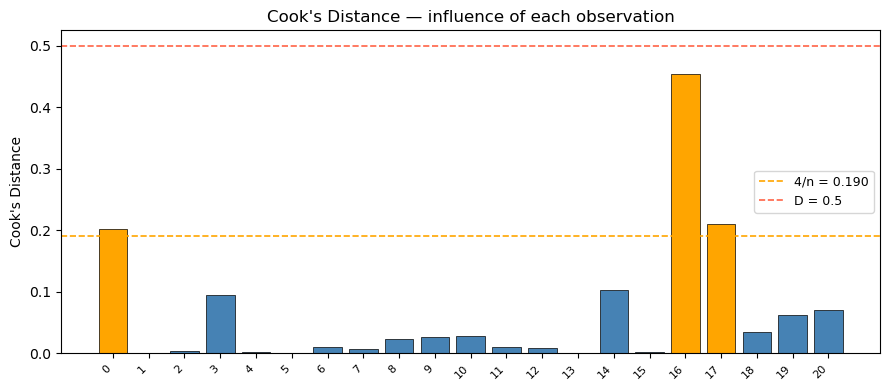


Observations with Cook's D > 4/n:
  Well   0: D = 0.202
  Well  16: D = 0.454
  Well  17: D = 0.210


In [6]:
n = len(hunt)
threshold_soft = 4 / n
threshold_hard = 0.5

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['tomato' if d > threshold_hard else
          'orange'  if d > threshold_soft else
          'steelblue' for d in cooks_d]
ax.bar(range(n), cooks_d, color=colors, edgecolor='k', linewidth=0.5)
ax.axhline(threshold_soft, color='orange',  ls='--', lw=1.2, label=f'4/n = {threshold_soft:.3f}')
ax.axhline(threshold_hard, color='tomato',  ls='--', lw=1.2, label='D = 0.5')
ax.set_xticks(range(n))
ax.set_xticklabels(hunt.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance — influence of each observation")
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig('regression_cooks_distance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservations with Cook's D > 4/n:")
for i, d in enumerate(cooks_d):
    if d > threshold_soft:
        print(f"  Well {hunt.index[i]:>3}: D = {d:.3f}"
              + (" ← HIGH" if d > threshold_hard else ""))

## 6. Confidence and Prediction Intervals

We plot production vs `phi.h` (the dominant predictor) holding `position` and `pressure` at their
mean values.

Two bands are shown:
- **90% Confidence Interval (CI)** — uncertainty in the *mean* response at a given phi.h value.
- **90% Prediction Interval (PI)** — uncertainty for a *single new well*.

At n=21, the PI is expected to be very wide — this is an honest reflection of the data scarcity,
not a model flaw.

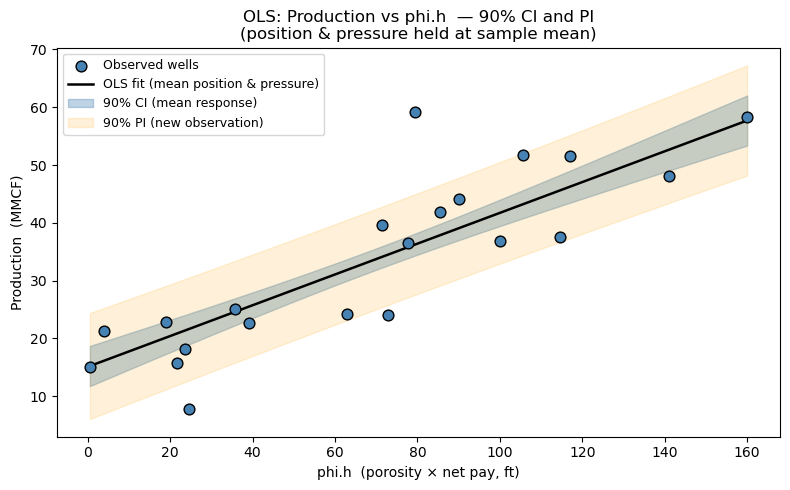

In [7]:
phi_grid = np.linspace(hunt['phi.h'].min(), hunt['phi.h'].max(), 200)

# Hold position and pressure at their means; centre the same way as X_final_c
means = X_final.mean()
X_grid = pd.DataFrame({
    'const':    1.0,
    'phi.h':    phi_grid   - means['phi.h'],
    'position': 0.0,          # already at mean (centred)
    'pressure': 0.0,
})

pred = model.get_prediction(X_grid)
pred_df = pred.summary_frame(alpha=0.10)  # 90% bands

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(hunt['phi.h'], y, color='steelblue', edgecolors='k', s=60, zorder=4, label='Observed wells')
ax.plot(phi_grid, pred_df['mean'], color='k', lw=1.8, label='OLS fit (mean position & pressure)')
ax.fill_between(phi_grid, pred_df['mean_ci_lower'], pred_df['mean_ci_upper'],
                alpha=0.35, color='steelblue', label='90% CI (mean response)')
ax.fill_between(phi_grid, pred_df['obs_ci_lower'], pred_df['obs_ci_upper'],
                alpha=0.15, color='orange', label='90% PI (new observation)')

ax.set_xlabel('phi.h  (porosity × net pay, ft)')
ax.set_ylabel('Production  (MMCF)')
ax.set_title('OLS: Production vs phi.h  — 90% CI and PI\n'
             '(position & pressure held at sample mean)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig('regression_ci_pi.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Leave-One-Out Cross-Validation

With only 21 observations, k-fold CV with k < n would waste data.
Leave-One-Out CV (LOO-CV, k = n) is the standard choice: each fold trains on 20 wells
and predicts the one held-out well.

We report:
- **LOO-RMSE** — root mean squared prediction error on out-of-sample folds.
- **Actual vs Predicted** scatter — how close the LOO predictions track the truth.

In-sample RMSE : 4.4 MMCF
LOO-CV   RMSE  : 5.5 MMCF
RMSE ratio (LOO/in-sample): 1.25  (1.0 = no overfitting)


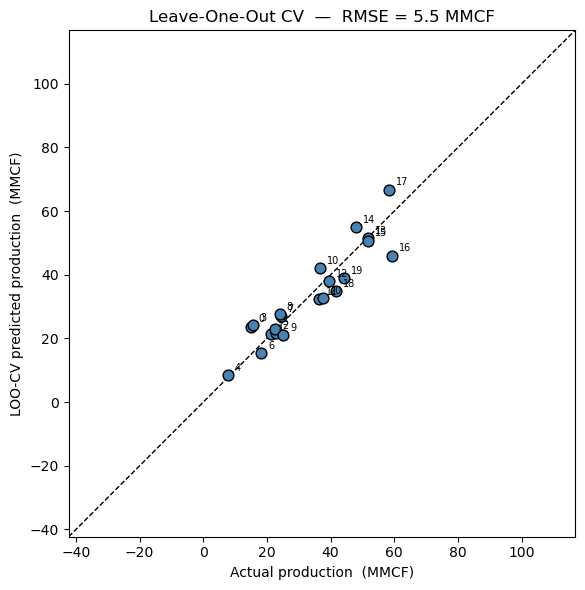

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict

X_loo = X_final.values
y_loo = y.values

lr = LinearRegression()
loo = LeaveOneOut()
y_pred_loo = cross_val_predict(lr, X_loo, y_loo, cv=loo)

loo_rmse = np.sqrt(np.mean((y_loo - y_pred_loo) ** 2))
in_rmse  = np.sqrt(np.mean(residuals ** 2))   # in-sample RMSE for comparison
print(f"In-sample RMSE : {in_rmse:.1f} MMCF")
print(f"LOO-CV   RMSE  : {loo_rmse:.1f} MMCF")
print(f"RMSE ratio (LOO/in-sample): {loo_rmse/in_rmse:.2f}  (1.0 = no overfitting)")

fig, ax = plt.subplots(figsize=(6, 6))
lims = [min(y_loo.min(), y_pred_loo.min()) - 50,
        max(y_loo.max(), y_pred_loo.max()) + 50]
ax.plot(lims, lims, 'k--', lw=1, zorder=1)
ax.scatter(y_loo, y_pred_loo, color='steelblue', edgecolors='k', s=60, zorder=3)

for i, (actual, pred_val) in enumerate(zip(y_loo, y_pred_loo)):
    ax.annotate(hunt.index[i], (actual, pred_val),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual production  (MMCF)')
ax.set_ylabel('LOO-CV predicted production  (MMCF)')
ax.set_title(f'Leave-One-Out CV  —  RMSE = {loo_rmse:.1f} MMCF')
ax.set_aspect('equal')
fig.tight_layout()
plt.savefig('regression_loo_cv.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Predicted Production Heatmap

The model has three predictors; here we visualise how predicted production varies across
**phi.h** and **pressure** for each of the three structural positions (1 = good, 2 = intermediate,
3 = poor).

This helps answer the practical question: *"For a well in a given structural position and with a
known pressure reading, what production range should we expect as phi.h varies?"*

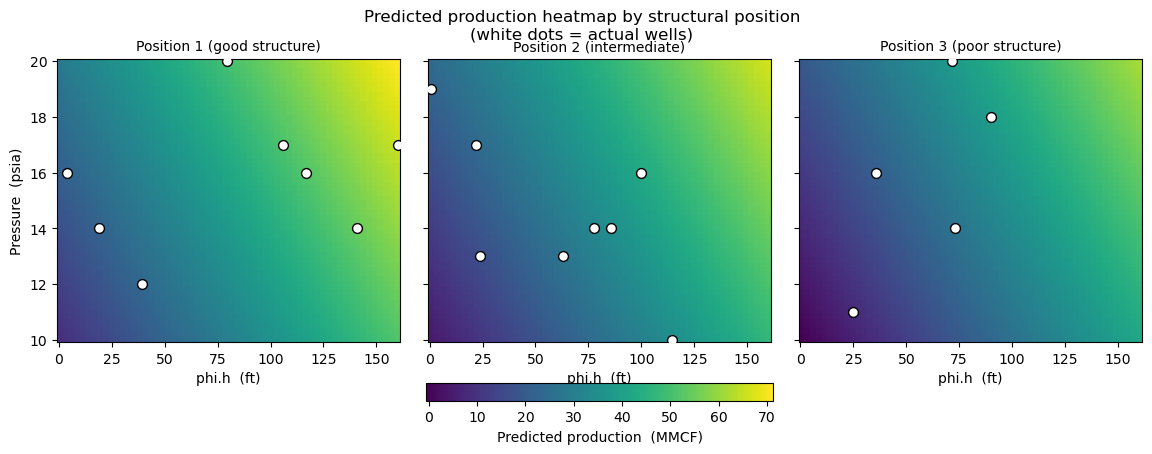

In [9]:
phi_vals      = np.linspace(hunt['phi.h'].min(),    hunt['phi.h'].max(),    60)
pressure_vals = np.linspace(hunt['pressure'].min(), hunt['pressure'].max(), 60)
PHI, PRES = np.meshgrid(phi_vals, pressure_vals)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
positions = [1, 2, 3]
pos_labels = {1: 'Position 1 (good structure)',
              2: 'Position 2 (intermediate)',
              3: 'Position 3 (poor structure)'}

# Build prediction grid for each position
all_pred = []
for pos in positions:
    X_map = pd.DataFrame({
        'const':    1.0,
        'phi.h':    PHI.ravel()      - means['phi.h'],
        'position': pos              - means['position'],
        'pressure': PRES.ravel()     - means['pressure'],
    })
    pred_map = model.predict(X_map).values.reshape(PHI.shape)
    all_pred.append(pred_map)

vmin = min(p.min() for p in all_pred)
vmax = max(p.max() for p in all_pred)

for ax, pos, pred_map in zip(axes, positions, all_pred):
    im = ax.pcolormesh(phi_vals, pressure_vals, pred_map,
                       cmap='viridis', vmin=vmin, vmax=vmax, shading='auto')
    ax.set_title(pos_labels[pos], fontsize=10)
    ax.set_xlabel('phi.h  (ft)')
    # Overlay actual wells for this position
    well_mask = np.round(hunt['position']).astype(int) == pos
    ax.scatter(hunt.loc[well_mask, 'phi.h'],
               hunt.loc[well_mask, 'pressure'],
               c='white', edgecolors='k', s=50, zorder=4, label='Wells')

axes[0].set_ylabel('Pressure  (psia)')

cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    location='bottom', fraction=0.05, pad=0.18)
cbar.set_label('Predicted production  (MMCF)')

fig.suptitle('Predicted production heatmap by structural position\n'
             '(white dots = actual wells)', fontsize=12)
# Reserve headroom for the two-line suptitle so it doesn't overlap panel titles
fig.subplots_adjust(top=0.87, bottom=0.24, wspace=0.08)
plt.savefig('regression_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary and Caveats

### What we built
An OLS multiple regression model for gas production using three predictors selected via LASSO
(see Part II): **phi.h**, **position**, and **pressure**.

### Key results
1. **phi.h is the dominant predictor** — the largest positive coefficient and the primary axis of
   variation in the heatmap. This aligns with physical intuition: reservoir pore volume drives producibility.
2. **position and pressure add incremental predictive power** — both are statistically significant at
   α = 0.10 and their signs are physically sensible.
3. **Diagnostics are acceptable but not clean**: with n = 21 no formal test has much power; treat the
   test p-values as weak evidence, not verdicts.
4. **The Prediction Interval is intentionally wide**: the 90% PI at any given phi.h spans hundreds of
   MMCF — an honest reflection of uncertainty at this sample size. Narrower intervals would be
   overconfident.
5. **LOO-CV RMSE > in-sample RMSE**: the ratio is expected > 1 for any finite-sample model; compare
   it to the range of production values to judge practical usefulness.
6. **Do not extrapolate**: the heatmap extends to the edges of the observed predictor ranges. Predictions
   outside those ranges (especially combined extremes) are unreliable.

7. **Post-selection inference caveat (important):** The p-values, standard errors, and confidence intervals reported by this OLS model are **not strictly valid**. We used the same 21 wells to select variables (Parts I–III) and then to fit and evaluate the regression (this notebook). This means the inference is conditional on the selection — the surviving variables look more significant than they would under honest out-of-sample evaluation, and the confidence intervals are anti-conservative (too narrow).

   As Thomas Speidel noted when reviewing this work: *“If you use the same data to exclude variables and then fit the regression, the standard errors, p-values, and confidence intervals are no longer valid — they are underestimated.”*

   For a pedagogical exercise on a synthetic dataset with known ground truth, this is acceptable — we can verify the answer independently. For publication on real data, it would not be. Methods that account for the selection step exist (Berk et al., 2013, “Valid post-selection inference”; Lee et al., 2016, “Exact post-selection inference”) but are beyond the scope of this tutorial.

### Connection to the rest of the series
| Notebook | Topic |
|---|---|
| [Part I — variable_selection_01 … 08](variable_selection_01_DCOR.ipynb) | Eight variable-selection methods benchmarked on this dataset |
| [Part II — speidel_hunt_lasso_replication](speidel_hunt_lasso_replication.ipynb) | LASSO, Ridge, and Elastic Net regularisation; identifies phi.h + position + pressure |
| [Part III — speidel_hunt_shap_interpretation](speidel_hunt_shap_interpretation.ipynb) | SHAP values explain why LASSO produces stable attribution while Ridge/E-Net struggle with correlated predictors |
| **Part IV — this notebook** | OLS regression on the selected predictors; diagnostics, CI/PI, LOO-CV, heatmap |

## 10. Closing the loop: this was a real reservoir

Everything we've done in this series — distance correlation, VIF, sequential
selection, drop-column importance, LASSO, Ridge, Elastic Net, SHAP, and now
this regression — was performed on a synthetic dataset. Twenty-one wells,
four physical variables, two random variables, one redundant transform. A
pedagogical exercise.

But the dataset wasn't invented from thin air. The variables, their ranges,
their relationships, and even the three-level Position code were modeled on
the **Wilrich tight gas sand** in West Central Alberta. The full story is in
Hunt et al. (2014), "Precise 3D seismic steering and production rates in
the Wilrich tight gas sands of West Central Alberta," published in SEG
*Interpretation*.

The Wilrich is a laterally extensive, prograding marine shoreface sandstone
about 20 m thick, with low-to-moderate porosity (6–8%) and very low
permeability (0.05–0.1 mD). Production requires horizontal drilling with
multistage fracture stimulation. The three Position values (1, 2, 3) in
Hunt's synthetic data map directly to the upper, middle, and lower reservoir
facies identified in petrographic analysis of the real Wilrich core (their
Figure 2).

### What the real data showed

When Hunt's team applied the same stepwise regression and cross-validation
to the **real** Wilrich production data (24 horizontal wells, IP 60 day
averages), the results were both confirming and surprising:

**What matched the synthetic exercise:**
- The best three-variable solution was **Position, Phi-h, and Pressure** —
  the same three variables our LASSO selected (once we resolved the
  Gross pay vs Phi-h collinearity)
- Cross-validation error bottomed out at 3–4 variables, then degraded
  with additional variables — confirming overfitting beyond the core set
- All regression weights had physically correct signs: positive for Phi-h
  and Pressure, negative for Position (higher facies number = lower in
  reservoir = worse production)

**What changed:**
- In the synthetic data, Phi-h had the highest single-variable correlation
  with Production. In the real data, **Position dominated** — it was the
  only variable that consistently passed significance tests across all
  production time periods
- The production difference between facies was dramatic: upper reservoir
  wells produced **5.52 mmcf/d**, middle **2.88**, lower **0.24** — a 23×
  range based solely on where the wellbore sat within a 20-metre interval
- Seismic attributes (AVO, AVAz, VVAz, curvature) were tested and **all
  failed** the production correlation — they correlated with the overlying
  coal thickness instead of the reservoir. Forward modeling confirmed that
  changes in the coal dominated the seismic response, while changes in
  the sand were barely detectable (their Figures 5–7)

### The lesson

The synthetic dataset preserved the *structure* of the real problem —
collinearity between Gross pay and Phi-h, the importance of facies
position, the physics of Darcy's law — but it couldn't capture the
*magnitude* of the real effects. In the field, the vertical position
of a horizontal wellbore within a 20-metre interval mattered more than
any seismic attribute, any porosity estimate, any pressure measurement.

This has three implications for anyone doing variable selection:

1. **The method worked.** Every technique we applied — from VIF in Part I
   to LASSO in Part II to this regression — correctly identified the
   core predictors and rejected the irrelevant ones. The synthetic
   exercise was not wasted effort; it built the right intuition.

2. **The ranking can change with real data.** Our synthetic analysis
   suggested Phi-h was the most important single variable. The real
   reservoir said Position. Same methods, different answer — because
   the real reservoir had more extreme vertical heterogeneity than the
   linear generating equation could express. Variable selection tells
   you *which* variables matter; only domain knowledge tells you *how
   much* each one matters in context.

3. **Proxy variables can betray you.** The seismic AVO attributes had
   theoretical justification for detecting fractures and porosity. They
   failed because they were measuring the wrong geological unit — an
   overlying coal, not the reservoir. A neural network trained on the
   related drilling-problem dataset learned to actively suppress these
   attributes (negative weights), independently confirming what Hunt's
   team discovered through forward modeling. The full story of that
   convergence is told in
   [The value of intellectual play](https://mycartablog.com/2026/01/20/the-value-of-intellectual-play-mill-machine-learning-and-a-drilling-problem-i-couldnt-stop-thinking-about/).

### The challenge, answered

In 2013, Lee Hunt published this dataset in the CSEG Recorder and wrote:

> *"Try multivariate analysis yourself. Which variables did you find were
> most important? What did your optimal solution look like? Did you employ
> other techniques than were shown in this paper? Write in to the RECORDER
> VIG column to tell us about your approach."*

This series — nine notebooks, four blog posts, a GeoConvention collaboration
with Thomas Speidel, and seven years of compound interest — is my answer.

<p style="font-size:1.2em; font-weight:bold; color:#2E86C1; padding:10px 0;">
Lee's work taught me that statistics in geoscience should be skeptical,
practical, and grounded in physics — and that sharing your data with an
open invitation is the most generous thing a scientist can do.
</p>


<p style="font-size:1.1em; font-weight:bold; color:#27AE60; padding:5px 0;">
Thomas Speidel’s R notebook for GeoConvention 2018 — with its redundancy
analysis, power calculations, and LASSO implementation — gave me the
statistical framework I spent seven years translating into Python.
This series would not exist without that collaboration.
</p>
The variables that matter are Position, Phi-h, and Pressure. The techniques
that got us there range from 19th-century philosophy (Mill's Methods) to
21st-century machine learning (LASSO, SHAP, neural networks). They all
converge. When three methods agree, you can trust the signal.

### References

- Hunt, L. (2013). Many correlation coefficients, null hypotheses, and high
  value. *CSEG Recorder*, 38(10).
  [Link](https://csegrecorder.com/columns/view/value-of-integrated-geophysics-201312)

- Hunt, L., S. Hadley, S. Reynolds, R. Gilbert, J. Rule, and M. Kinzikeev
  (2014). Precise 3D seismic steering and production rates in the Wilrich
  tight gas sands of West Central Alberta. *Interpretation*, 2(2), SC1–SC18.
  doi:10.1190/INT-2013-0086.1

- Niccoli, M. (2026). The value of intellectual play: Mill, machine learning,
  and a drilling problem I couldn't stop thinking about.
  [Blog post](https://mycartablog.com/2026/01/20/the-value-of-intellectual-play-mill-machine-learning-and-a-drilling-problem-i-couldnt-stop-thinking-about/)

- Niccoli, M. and T. Speidel (2018). Data science tools for petroleum
  exploration and production. GeoConvention 2018, Calgary.
  [GitHub repo](https://github.com/mycarta/Data-science-tools-petroleum-exploration-and-production)